# Lecture 14: Descriptive Statistics, Correlation & Frequency Analysis

### Dataset: Walmart Sales Dataset  
### Goal: Learn how to summarize data, find relationships, and analyze category distributions

## Why This Matters

Before building models or dashboards, we must understand the data:
- What is normal?
- What is unusual?
- What variables matter most?

# **Content -**
Descriptive Statistics
*   Central Tendency (Mean vs Median)
*   Dispersion (Std Dev, Quantiles)

Frequency Analysis
*   value_counts()
*   pd.crosstab()

Correlation Analysis
*   Understanding Relationships
*   df.corr()

## Dataset Setup

We will work with a custom car dataset created directly in the notebook.
This avoids external file dependencies and keeps the focus on logic.

In [ ]:
import pandas as pd

In [ ]:
# Custom dataset for Lecture 14


data = {
    'Price': [12000, 15000, 9000, 18000, 22000, 14000, 16000, 8000, 20000, 17000,
              11000, 13000, 21000, 9500, 15500, 14500, 16500, 18500, 12500, 17500,
              25000, 35000],

    'Age': [5, 3, 12, 2, 1, 6, 4, 15, 2, 3,
            8, 7, 1, 14, 4, 6, 5, 2, 9, 3, 2, 4],

    'KM': [50000, 30000, 90000, 20000, 10000, 60000, 45000, 120000, 15000, 25000,
           70000, 65000, 8000, 110000, 48000, 58000, 52000, 22000, 75000, 27000,
           10000, 20000],

    'FuelType': ['Petrol', 'Diesel', 'Petrol', 'Diesel', 'Hybrid',
                 'Petrol', 'Diesel', 'Petrol', 'Hybrid', 'Diesel',
                 'Petrol', 'Petrol', 'Hybrid', 'Diesel', 'Petrol',
                 'Diesel', 'Petrol', 'Hybrid', 'Diesel', 'Petrol',
                 'Electric', 'Electric'],

    'HP': [90, 110, 85, 120, 130, 95, 105, 80, 140, 115,
           92, 98, 135, 88, 108, 102, 100, 125, 96, 112,
           100, 96],

    'Automatic': [0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
                  0, 0, 1, 0, 1, 1, 0, 1, 0, 1,
                  0, 1],

    'Doors': [4, 4, 3, 4, 5, 4, 4, 3, 5, 4,
              4, 4, 5, 3, 4, 4, 4, 5, 4, 4,
              4, 5],

    'Weight': [1100, 1200, 1050, 1300, 1400, 1150, 1250, 1000, 1450, 1350,
               1120, 1180, 1420, 1080, 1230, 1210, 1190, 1380, 1160, 1320,
               1000, 1150]
}

df = pd.DataFrame(data)

# Let's analyze the first 5 columns
df.head()

Fact: .shape is an attribute that only returns tuple, and not a function. That's why we won't be using **()**

In [ ]:
df.shape

df.columns

At a high level, this dataset contains:
- Numeric attributes (Price, Age, KM, HP, Weight, Doors)
- Categorical attributes (FuelType)
- Boolean-like attributes (Automatic: 0 = Manual, 1 = Automatic)

# **Section 1: Descriptive Statistics**
Before diving into deep analysis, we must understand the "typical" profile of our data.

In [ ]:
df.describe()

,Price,Age,KM,HP,Automatic,Doors,Weight
count,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000
mean,16386.363636,5.363636,46818.181818,105.545455,0.545455,4.090909,1213.181818
std,5993.909246,4.030189,32109.390947,16.372821,0.509647,0.610159,132.786487
min,8000.000000,1.000000,8000.000000,80.000000,0.000000,3.000000,1000.000000
25%,12625.000000,2.250000,20500.000000,95.250000,0.000000,4.000000,1127.500000
50%,15750.000000,4.000000,46500.000000,101.000000,1.000000,4.000000,1195.000000
75%,18375.000000,6.750000,63750.000000,114.250000,1.000000,4.000000,1315.000000
max,35000.000000,15.000000,120000.000000,140.000000,1.000000,5.000000,1450.000000


In [ ]:
df['Price'].mean()

In [ ]:
df['Price'].std()

# Check-point 1:

Question 1:

Looking at the describe() output, which column has the highest variation (relative to its mean)?

Question 2 :

If we added a "Vintage Luxury Car" priced at 500,000 to our dataset, what would happen to the Mean vs the Median?

# Section 2: **Frequency** **Analysis**
Now, let's look at categorical distributions.

How common is each fuel type?

In [ ]:
df['FuelType'].value_counts()


,count
FuelType,
Petrol,9
Diesel,7
Hybrid,4
Electric,2


In [ ]:
df['FuelType'].value_counts(normalize=True) * 100


,proportion
FuelType,
Petrol,40.909091
Diesel,31.818182
Hybrid,18.181818
Electric,9.090909


What if we want to see the distribution of FuelType against another category?

In [ ]:
pd.crosstab(df['FuelType'], df['Doors'])

Doors,3,4,5
FuelType,,,
Diesel,1,6,0
Electric,0,1,1
Hybrid,0,0,4
Petrol,2,7,0


# Check-point 2:

Question: Which fuel type is most prevalent in our dataset? Does any fuel type only appear with a specific number of doors?

# **Section 3 : Correlation Analysis**
This is the most important part of EDA—finding how variables move together.

Interpreting the numbers:

+1.0: Perfect positive relationship (as X goes up, Y goes up).

-1.0: Perfect negative relationship (as X goes up, Y goes down).

0.0: No relationship.


In [ ]:
# Correlation only works on numeric variables
# Pandas automatically ignores categorical columns like FuelType

In [ ]:
corr = df.corr(numeric_only=True)
corr

,Price,Age,KM,HP,Automatic,Doors,Weight
Price,1.000000,-0.684208,-0.780605,0.467452,0.520085,0.745127,0.353770
Age,-0.684208,1.000000,0.976416,-0.795530,-0.680762,-0.808038,-0.707891
KM,-0.780605,0.976416,1.000000,-0.796893,-0.680389,-0.823074,-0.680913
HP,0.467452,-0.795530,-0.796893,1.000000,0.750176,0.771765,0.936831
Automatic,0.520085,-0.680762,-0.680389,0.750176,1.000000,0.598609,0.775295
Doors,0.745127,-0.808038,-0.823074,0.771765,0.598609,1.000000,0.730932
Weight,0.353770,-0.707891,-0.680913,0.936831,0.775295,0.730932,1.000000


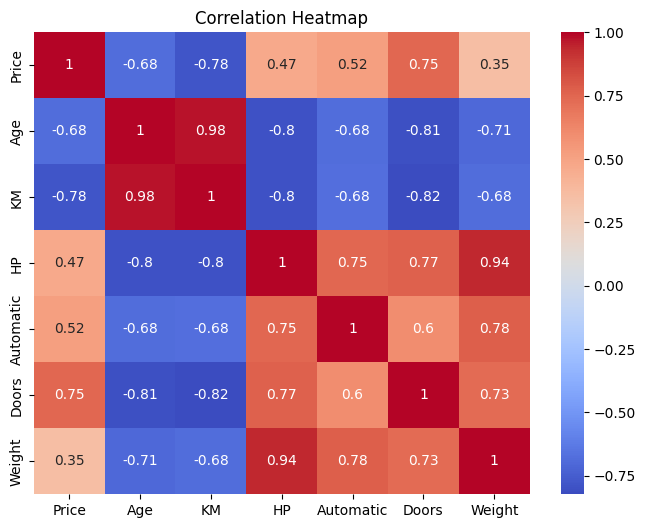

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Interpretation:**
- Negative correlation between Age & Price → Older cars cheaper
- Positive correlation between HP & Price → Powerful cars cost more
- Age and KM correlation ≈ 0.98; Older cars almost always have higher mileage.



# Check Point 3

*   Outlier Check: What is the max Price? Is it significantly higher than the 75% (Q3)?


*  Efficiency Check: Is there a correlation between HP (Horsepower) and KM (Mileage)?


*   Market Share: What percentage of cars in this dataset are 'Diesel'?






# In-Class Coding Challenge -

Task: You are a car dealer.




1. Find the Standard Deviation of KM. If it's high, it means our stock has a very varied usage history.

In [ ]:
km_std = df['KM'].std()
km_std
# Analysis: A high STD (relative to the mean) suggests a wide variety of usage levels in the inventory.

2. Use value_counts on Automatic but only for cars with Price > 15000.

In [ ]:
high_end_auto = df[df['Price'] > 15000]['Automatic'].value_counts()

high_end_auto

3. Identify the "Best Value" car: Create a column Price_per_HP. Find the car with the minimum value in this column.

In [ ]:
df['Price_per_HP'] = df['Price'] / df['HP']
best_value_idx = df['Price_per_HP'].idxmin()
best_value_car = df.loc[best_value_idx]

print(f"The best value car is at index {best_value_idx} with a Price/HP of {df['Price_per_HP'].min():.2f}")
print(best_value_car)

# Post-Class Practice Questions -
**Question 1: Categorical Filtering**

Find the frequency distribution (value_counts) of FuelType only for cars that have more than 100 HP.

**Question 2: The Skewness Hunt**
Compare the Mean and Median of the KM column.

- If Mean > Median, print "Right Skewed".
- If Mean < Median, print "Left Skewed".
- If they are equal, print "Symmetric".

**Question 3: Deep Relationship Analysis**

Create a crosstab between FuelType and a new column called Is_Expensive. (Hint: Is_Expensive should be True if Price is above the median, else False).

**Question 4: Specific Correlation**

Calculate the correlation specifically between Age and KM.

Bonus: Why would a car dealer care about this specific number?

**Question 5: Outlier Identification**

Calculate the Interquartile Range (IQR) for Price. (IQR = 75th percentile - 25th percentile). Find all cars where the Price is greater than Q3 + (1.5 * IQR). These are your luxury outliers!